### Simple Linear Regression

## Steps 

### 1. import all necessary libraries
### 2. import data and perfome cleaning etc
### 3. split the data and make it standard
### 4. train the model and do prediction
### 5. Evaluation and visualization
### 6. export the model into joblib

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
df = pd.read_csv('HeightWeight.csv').drop(columns='Index')
df.head()

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


In [5]:
X = df[['Weight(Pounds)']]
y = df[['Height(Inches)']]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [7]:
scaler = StandardScaler()

In [8]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [11]:
# print(X_test.shape[1])
# print(len(y_test))

1
5000


In [31]:
regressor = LinearRegression()

In [32]:
regressor.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.95]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[67.99]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[141.42]


In [33]:
print("the coffeficent is : ", regressor.coef_)
print("the intercept is : ", regressor.intercept_)

the coffeficent is :  [[0.95022131]]
the intercept is :  [67.99034523]


In [34]:
y_pred = regressor.predict(X_test_scaled)

In [35]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
# adjusted_r2 = 1 - [(1-r2)*(n-1)/(n-k-1)]
# n : total number of the data point (sample size) 
# k : number of independent variables (features)

adjusted_r2 = 1 - (((1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)))

In [36]:
print(f"The Mean Square Error (MSE) : {mse:.2f}")
print(f"The Mean Absolute Error (MAE) : {mae:.2f}")
print(f"The Root Mean Square Error (RMSE) : {rmse:.2f}")
print(f"The R2 score (R2) : {r2:.2f}")
print(f"The Adjusted R2 (Adj_R2) : {adjusted_r2:.2f}")

The Mean Square Error (MSE) : 2.72
The Mean Absolute Error (MAE) : 1.32
The Root Mean Square Error (RMSE) : 1.65
The R2 score (R2) : 0.26
The Adjusted R2 (Adj_R2) : 0.26


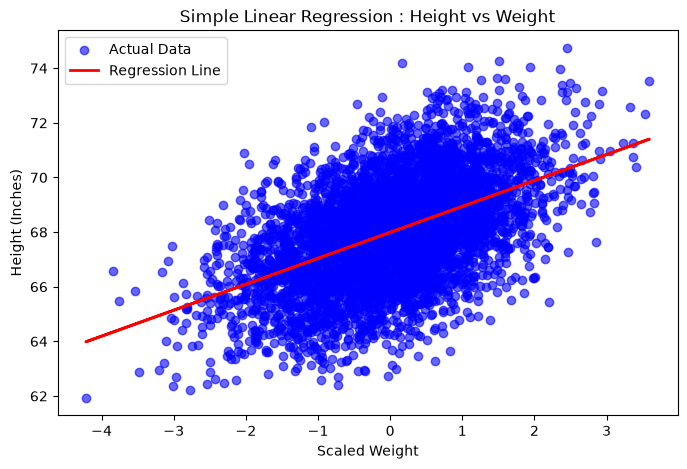

In [37]:
plt.figure(figsize = (8,5))
plt.scatter(X_test_scaled, y_test, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test_scaled, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Scaled Weight")
plt.ylabel("Height (Inches)")
plt.title('Simple Linear Regression : Height vs Weight')
plt.legend()
plt.show()

In [38]:
import joblib

joblib.dump(regressor, 'linear_regression_model.joblib')
joblib.dump(scaler, 'standard_scaler.joblib')
print("Artifacts saved sucessfully!")

Artifacts saved sucessfully!
